# Exploring Corpus

This notebook explores and describes the corpus. This is done to verify if paper processing into the corpus had gone correctly. (quality of data)

- Header names exploration
- What is the frequency of words in sentences (group Parkinson vs non-Parkinson)?
- How many words are there in a sentence?
- How many sentences are there in a paper?

### Settings

In [1]:
experiment_name = "free_1000_251013_pest_PD"

## Initialisation

In [81]:
# meta
__author__ ="Jennefer Beenen"
__version__ = "1.0"
__email__ = "j.beenen@pl.hanze.nl"
__status__ = "Development"
# __date__ = "2025-05-06"

### Imports

In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# https://amueller.github.io/word_cloud/
from wordcloud import WordCloud
from wordcloud import STOPWORDS

import nltk
import math

from sentence_transformers import SentenceTransformer

/homes/jbeenen/venv/graduation_3_13_5/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-15 16:28:53.466945: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-15 16:28:53.529319: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-15 16:28:58.019753: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You m

### Functions

In [56]:
def unique_values_per_column(df: pd.DataFrame):
    """Prints the unique values found in each column of a data frame."""
    for column in df.columns:
        if df[column].nunique() < 25:
            print(f"'{column}' ({df[column].nunique()}):\n{df[column].unique()}\n")
        else:
            print(f"'{column}' ({df[column].nunique()}): (only first 25 values are shown)\n{df[column].unique()[:25]}\n")

def df_describe_not_norm(series):
    """Return dataframe with describing values for a non-normal distribution."""
    # create dataframe with median, min, and max
    new_df = pd.DataFrame.from_dict({
            "count": series.shape[0],
            "median": series.median(),
            "min": series.min(),
            "max": series.max()
    }, orient= 'index').T

    # add value range
    new_df['range'] = new_df['max'] - new_df['min']

    return new_df.T

def get_sentences(series, keywords: list, inverse: bool = False) -> list:
    """Get sentences from series that contains the keyword, or sentences without the keyword by setting `inverse` to `True`."""
    # Make all sentence_text lower case & remove puntuations
    # https://www.geeksforgeeks.org/python/generating-word-cloud-python/
    series = series.str.lower().str.strip('.?!')

    # Check if type(`keywords`) == list
    if isinstance(keywords, list):
        if inverse:
            # Search for sentences that exclude `keywords`
            # Note: Copilot brought to my attention that `series.str.contains` exists
            # and that it can handle a list by creating a regex expression with "|".join()
            sentences = series.loc[~series.str.contains("|".join(keywords))]
            # Report number of sentences found
            print(f"{len(sentences)} sentences were found without '{keywords}'.")   
        else:
            # Search for sentences that include `keywords`
            sentences = series.loc[series.str.contains("|".join(keywords))].values
            # Report number of sentences found
            print(f"{len(sentences)} sentences were found with '{keywords}'.")

        # (Ready to create wordcloud)
        return sentences
    else:
        raise TypeError(f"Data type of `keywords` is ({type(keywords)}) instead of (list).")

def remove_PD_and_pest_from_sentence(sentences: list, remove_word: str = '', remove_PD: bool = False, remove_pest: bool = False) -> list:
    """Remove "pesticides", "pesticide", and "parkinson's disease" from strings in `sentences`."""

    if remove_pest:
        sentences = [sent.replace("pesticide", "")
            for sent in [
                sent.replace("pesticides", "")
                for sent in sentences
            ]
        ]

    # if remove_PD:
    #     sentences = [sent.replace("parkinson's disease", "")
    #         for sent in sentences
    #     ]
    
    if len(remove_word) > 0:
        sentences = [sent.replace(remove_word, "")
            for sent in sentences
        ]
    
    return sentences

def create_wordcloud(sentences: list, collocations: bool= True):
    """Create WordCloud object, 16:9 ratio, top 100 words."""
    # Create WordCloud object, 16:9 ratio, top 100 words
    wordcloud = WordCloud(
        width=1600,
        height=900,
        max_words= 100,
        stopwords= STOPWORDS.update(['one', 'two', 'three', 'first', 'study', 'wa', 'ha']),
        colormap= 'PiYG',
        collocations = collocations,
    ).generate(" ".join(sentences)) # join words to form one long 'sentence'

    # Plot
    plt.imshow(wordcloud)
    plt.axis('off')

In [4]:
# Code written by Michiel Noback, with minor adjustments by Jennefer Beenen.
class Tokenizer:
    '''class for tokenizing text data using nltk.word_tokenize(). Author: Michiel Noback.'''
    def __init__(self, stop_words: list, min_length: int=2, lemmatize: bool=True, remove_digits: bool=True):
        self.min_length = min_length
        self.lemmatize = lemmatize
        self.stop_words = stop_words
        self.remove_digits = remove_digits

    def __call__(self, s):
        return self.tokenize_text(s)
    
    def tokenize_text(self, s):
        '''tokenizes the text data'''
        # split string into words (tokens)
        tokens = nltk.tokenize.word_tokenize(s)

        # remove short words, they're probably not useful
        tokens = [t for t in tokens if len(t) >= self.min_length]

        if self.lemmatize:
            lemmatizer = nltk.stem.WordNetLemmatizer()
            # put words into base form
            tokens = [lemmatizer.lemmatize(t) for t in tokens]

        if self.stop_words:
            # remove stopwords
            tokens = [t for t in tokens if t not in self.stop_words]
        if self.remove_digits:
            # remove any digits, i.e. "3rd edition"
            tokens = [t for t in tokens if not any(c.isdigit() for c in t)]

        return tokens
    
def get_word_counts(lists: list, tokenizer) -> dict:
    """Author: Michiel Noback."""
    counts = {}
    for abstr in lists:
        words = tokenizer.tokenize_text(abstr)
        for word in words:
            counts[word] = counts.get(word, 0) + 1
    return counts

def normalize_counts(count_dict: dict):
    "Author: Michiel Noback."
    # first pass to get totals
    word_count = 0
    for (word, count) in count_dict.items():
        word_count += count
    print(f'total word count: {word_count}')

    # second pass to normalize
    for (word, count) in count_dict.items():
        count_dict[word] = count_dict[word] / word_count
    return count_dict

def filter_word_counts(word_counts, top_n = 1000):
    '''Author: Michiel Noback. Filters low-occurring words; only keeps the top-n words'''
    filtered = dict()
    
    for i, item in enumerate(sorted(word_counts.items(), 
                                    key=lambda x: x[1], 
                                    reverse=True), 
                             start=1):
        filtered[item[0]] = item[1]
        if i == top_n:
            # may never be reached with small sets
            break
            
    return filtered

def subtract_word_counts(set1, set2, top_n=1000):
    '''set2 will be subtracted from set1. Only the top_n words in set1 will be returned. Author: Michiel Noback.'''
    set1 = set1.copy()
    for (word, _) in set2.items():
        if word in set1:
            set1[word] = set1[word] - set2[word]
    return filter_word_counts(set1, top_n)

def word_list(normalized_word_dict: dict, expand_factor: int=1000):
    """Author: Michiel Noback."""
    for (word, _) in normalized_word_dict.items():
        ## expand back to integer counts
        normalized_word_dict[word] = math.ceil(normalized_word_dict[word] * expand_factor)
    # print(normalized_word_dict)
    ## make the string
    word_list = [' '.join([word] * count) for (word, count) in normalized_word_dict.items()]
    return word_list

### Load data

In [5]:
# load data
filename = f'corpus_{experiment_name}'
df = pd.read_csv(f'../../data/corpus/{filename}.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30484 entries, 0 to 30483
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   paper_id       30484 non-null  int64 
 1   paper_name     30484 non-null  int64 
 2   head_id        30484 non-null  int64 
 3   head_name      30484 non-null  object
 4   paragraph_id   30484 non-null  int64 
 5   sentence_id    30484 non-null  int64 
 6   sentence_text  30484 non-null  object
dtypes: int64(5), object(2)
memory usage: 1.6+ MB


In [87]:
df.head()

,paper_id,paper_name,head_id,head_name,paragraph_id,sentence_id,sentence_text
0,0,17900545,0,title,0,0,EPIGALLOCATECHIN GALLATE (EGCG) POTENTIATES TH...
1,0,17900545,1,Introduction,0,0,A number of studies suggest that oxidative str...
2,0,17900545,1,Introduction,0,1,Rotenone is a complex 1 inhibitor and is one o...
3,0,17900545,1,Introduction,0,2,This pesticide increases the formation of ROS ...
4,0,17900545,1,Introduction,1,0,Plant polyphenols are commonly considered as d...


### Replace 'PD' with "parkinson's disease"

I'm expecting Parkinson's Disease to be often abbreviated to PD. This abbreviation will then be visible in the word clouds that are generated in this notebook. In order to filter on "parkinson's disease" we will need to replace this abbreviation ("PD" to "parkinson's disease").

In [6]:
# Current state:
df.head()

,paper_id,paper_name,head_id,head_name,paragraph_id,sentence_id,sentence_text
0,0,17900545,0,title,0,0,EPIGALLOCATECHIN GALLATE (EGCG) POTENTIATES TH...
1,0,17900545,1,Introduction,0,0,A number of studies suggest that oxidative str...
2,0,17900545,1,Introduction,0,1,Rotenone is a complex 1 inhibitor and is one o...
3,0,17900545,1,Introduction,0,2,This pesticide increases the formation of ROS ...
4,0,17900545,1,Introduction,1,0,Plant polyphenols are commonly considered as d...


In [7]:
# Check if "PD" can mean Parkinson.
PD_indexes = df['sentence_text'].str.findall("PD").str.len() > 0
# Show
df.loc[PD_indexes, 'sentence_text'].values

array(['The present work was carried out to determine to what extent EGCG would modulate the cytotoxic effects of rotenone in SH-SY5Y neuroblastoma cells, a commonly used cellular PD model.',
       "The degeneration of LC/NE neurons is detected in multiple neurodegenerative diseases, such as Alzheimer's disease (AD) and Parkinson's disease (PD).",
       'Postmortem studies demonstrated that the loss of LC/NE neurons is greater and may be earlier than that of nigral dopaminergic neurons in patients with PD.',
       ...,
       'It is thought that in disorders such as PD, DLB and MS, protein degradation is much slower than the development of misfolded proteins.',
       'However, resection of autonomic neurons prevented the PD-like pathology progression in these mice.',
       "As experimental and epidemiological data suggest, many neurodegenerative disorders, including PD, are the result of the complex interaction between an individual's underlying genetic composition, lifestyle and 

As shown above. PD often used as an abbreviation for parkinson's disease.
(also see https://www.ncbi.nlm.nih.gov/books/NBK536722/)

In [8]:
# Replace " PD " with " parkinson disease ".
df['sentence_text'] = df['sentence_text'].str.replace("PD", "parkinson's disease", case= True)
# Show if correction was successful 
df.loc[PD_indexes, 'sentence_text'].values

array(["The present work was carried out to determine to what extent EGCG would modulate the cytotoxic effects of rotenone in SH-SY5Y neuroblastoma cells, a commonly used cellular parkinson's disease model.",
       "The degeneration of LC/NE neurons is detected in multiple neurodegenerative diseases, such as Alzheimer's disease (AD) and Parkinson's disease (parkinson's disease).",
       "Postmortem studies demonstrated that the loss of LC/NE neurons is greater and may be earlier than that of nigral dopaminergic neurons in patients with parkinson's disease.",
       ...,
       "It is thought that in disorders such as parkinson's disease, DLB and MS, protein degradation is much slower than the development of misfolded proteins.",
       "However, resection of autonomic neurons prevented the parkinson's disease-like pathology progression in these mice.",
       "As experimental and epidemiological data suggest, many neurodegenerative disorders, including parkinson's disease, are the re

Note that the code above is also used in `corpus_by_sentence2vectors.py` before embedding sentences.

In [9]:
# Make all sentence_text lower case & remove punctuations
# https://www.geeksforgeeks.org/python/generating-word-cloud-python/
df['sentence_text'] = df['sentence_text'].str.lower().str.strip('.?!')

In [10]:
# Search for sentences that include 'Parkinson'
sentences = df.loc[df['sentence_text'].str.findall("parkinson's disease").str.len() > 0, 'sentence_text'].values
sentences

array(["a number of studies suggest that oxidative stress that results in the excess production of reactive oxygen species may be involved in the development of neurodegenerative disorders such as parkinson's disease",
       "rotenone is a complex 1 inhibitor and is one of the common neurotoxic agents used to examine the development of parkinson's disease in animal models",
       "the present work was carried out to determine to what extent egcg would modulate the cytotoxic effects of rotenone in sh-sy5y neuroblastoma cells, a commonly used cellular parkinson's disease model",
       ...,
       "it is thought that in disorders such as parkinson's disease, dlb and ms, protein degradation is much slower than the development of misfolded proteins",
       "however, resection of autonomic neurons prevented the parkinson's disease-like pathology progression in these mice",
       "as experimental and epidemiological data suggest, many neurodegenerative disorders, including parkinson's di

Note that total number of sentences has now increased: 

5974: when searching only on "PD".           

6490: now together with "parkinson's disease".

## Header names exploration

We would like to know what different headers are used throughout the different papers.

In [ ]:
# explore unique values
unique_values_per_column(df)

: 

I did not expect to find "Western blot and tandem mass spectrometric analysis of protein-HNE adducts" in `head_name`. Let's check out if parsing went correct.

In [ ]:
df[df["head_name"] == "Western blot and tandem mass spectrometric analysis of protein-HNE adducts"] 

: 

After checking the paper (PMID 17900545); "Western blot and tandem mass spectrometric analysis of protein-HNE adducts" is found to be a section from "Results". So these are parsed correctly.

I want to check if the longest headers are correct:

In [ ]:
# Display more characters in printed data frames
pd.set_option('display.max_colwidth', 110)

: 

In [ ]:
# Select only unique 'paper_name' and 'head_name' combinations
selection = df[['paper_name','head_id','head_name']].drop_duplicates()

# Sort selection on 'head_name' string length
df.loc[selection['head_name'].str.len().sort_values(ascending=False).index, ['paper_name', 'head_name']]

: 

I checked the longest two "head_name"s and they are correctly parsed. The shortest headers though, appear to be incorrectly parsed, so let's check that out as well.

In [ ]:
# Sort selection on 'head_name' string length
df.loc[selection['head_name'].str.len().sort_values().index].head(5)

: 

All three papers (30248838, 23950519, and 29209747) we have checked that contained short header names (‘•’, ‘i’, ‘3’, respectively) contain type of parsing error: 30248838 ‘•’ is a bullet in a highlight section, 23950519 ‘i’ is the first letter of the sentence in drop cap style, for 29209747 ‘3’ I have no idea where the number 3 comes from, but the sentence starts on a new page.

In [ ]:
# turn all head_name s to lower case
df['head_name'] = df['head_name'].str.lower()

: 

In [ ]:
# plot the distribution of the 'head_name' column
df.groupby(['head_name'])['paper_id'].nunique().sort_values(ascending=False).head(20).plot(kind='bar', figsize=(10, 6))

# annotate value above each bar
for i, v in enumerate(df.groupby(['head_name'])['paper_id'].nunique().sort_values(ascending=False).head(20)):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.title('Header name frequency by paper')
plt.ylabel('Number of unique papers')
# plt.xticks(rotation=45)
plt.xlabel('')
plt.tight_layout()
plt.show()

: 

The naming of headers appears to be inconsistent with different spellings: “conclusion” and “conclusions”, “acknowledgments” and “acknowledgements”. 

Some papers appear to miss a title.

In [ ]:
# Some papers appear to miss a 'title'
print(f"{df.groupby(['head_name'])['paper_id'].nunique()['title']} out of {df['paper_id'].nunique()} papers have a title.")

: 

Get the PMIDs of those papers to inspect if this is correct.

In [ ]:
# set paper_id that have a title
set_paper_id_with_title  = set(df.groupby(['head_name'])['paper_id'].unique()['title'])

# reference set (range(min, max))
set_ref = set(np.arange(min(set_paper_id_with_title), max(set_paper_id_with_title), 1))

# Create list with paper_ids that do not have a title
list_paper_id_without_title = list(set_ref - set_paper_id_with_title)
# Get PMIDs of papers that do not have a title
df[df["paper_id"].isin(list_paper_id_without_title)]["paper_name"].unique()

: 

For PMID 23544381 this appears to be true. For PMID 35393289, 30099890, and 28379585 this appears to be incorrect, GROBID also appears to have failed to parse the abstract section of these papers (see code below).

In [ ]:
# Checking if a sentence in the abstract is found in the corpus
df[
    (df['paper_name'] == 35393289) &
    (df['sentence_text'] == "Assessment of occupational pesticide exposure in epidemiological studies of chronic diseases is challenging".lower())
]

: 

In [ ]:
# Checking if a sentence in the abstract is found in the corpus
df[
    (df['paper_name'] == 30099890) &
    (df['sentence_text'] == "In parkinson's disease patients as well as in animal models for parkinson's disease, alpha-synuclein-positive enteric neurons in the colon and evidence of colonic inflammation have been demonstrated".lower())
]

: 

## Frequency words (wordcloud)

The following wordclouds will gain us insights if further parsing the papers went correctly.

Wordcloud python library works the best with English words (for auto removing stopwords) and removes "'s" from text. See [documentation](https://amueller.github.io/word_cloud/_modules/wordcloud/wordcloud.html#WordCloud).

**NOTE:** Keep in mind that the processed papers are already biased to (pesticides AND parkinson's disease).

#### Do all papers contain information about pesticides and PD?

In [ ]:
# Number of unique papers in corpus
nu_total = df['paper_name'].nunique()

# Number of unique papers that have a sentence where "pesticides" or "PD" are mentioned
nu_mentioned = df.loc[
    df['sentence_text'].str.contains(
        "|".join([
            "pesticide", 
            "parkinson's disease"
        ]),
    ), 
    'paper_name'
].nunique()

# Test if each paper contain information about pesticides or PD. (If yes, then print should say `True`)
nu_total == nu_mentioned

: 

Although, there are papers that do not appear to mention pesticides and PD: 

In [ ]:
# Number of unique papers in corpus
nu_total = df['paper_name'].unique()

# Number of unique papers that have a sentence where both "pesticide" are mentioned
nu_mentioned_pest = df.loc[
    df['sentence_text'].str.contains("pesticide"),
    'paper_name'
].unique()

# Number of unique papers that have a sentence where both "pesticide" and "PD" are mentioned
nu_mentioned_park = df.loc[
    df['sentence_text'].str.contains("parkinson's disease"), 
    'paper_name'
].unique()

# Set with PMIDs that are only about "parkinson's"
papers_without_pest = set(nu_total) - set(nu_mentioned_pest)

# Set with PMIDs that are only about "pesticide"
papers_without_park = set(nu_total) - set(nu_mentioned_park)

# Show titles of PMIDs
df[
    (df['paper_name'].isin(papers_without_pest | papers_without_park))
    &
    (df['head_name'] == 'title')
][['paper_name','sentence_text']].values

: 

Among the 152 papers, 142 mention both “pesticide” and “Parkinson’s disease” at least once. This number may be underestimated, as incomplete parsing by the PDF-to-XML process could have prevented full text extraction. Of the remaining papers, two mention only “pesticide”, while eight mention only “Parkinson’s disease”.

### Combined Parkinson's disease & Pesticides

#### All sentences

30484 sentences.


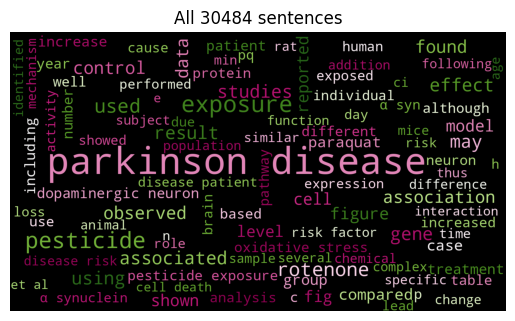

In [94]:
# All sentences (incl. "Parkinson's disease" and "pesticide(s)")
print(f"{df["sentence_text"].shape[0]} sentences.")
create_wordcloud(
    df["sentence_text"].values
)
plt.title('All 30484 sentences')
plt.show()

30484 sentences.


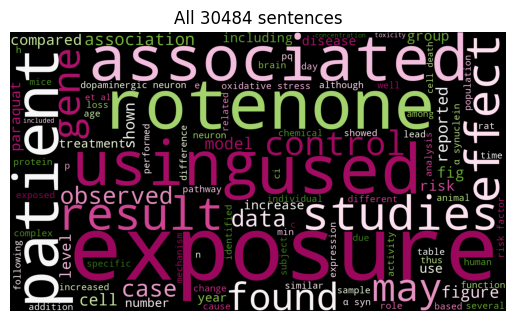

In [95]:
# All sentences
print(f"{df["sentence_text"].shape[0]} sentences.")
create_wordcloud(
    remove_PD_and_pest_from_sentence(
        df["sentence_text"].values
    )
)
plt.title('All 30484 sentences')
plt.show()

#### Differential wordclouds

Code for making differential wordcloud was used from Michiel Noback.

In [11]:
# the custom class Tokenizer can also lemmatize, and remove short words, digits and stopwords
tokenizer = Tokenizer(
    stop_words= list(STOPWORDS),
    min_length=3
)

##### "pesticides" AND/OR "parkinson's disease"

In [57]:
# Complete pipeline
filtered_without_PD_pest = filter_word_counts(
    normalize_counts(
        get_word_counts(
            remove_PD_and_pest_from_sentence(
                get_sentences(
                    df["sentence_text"],
                    ["pesticide", "parkinson's disease"],
                    inverse= True
                ),
                remove_pest= True,
                remove_word= "parkinson's disease"
            ),
            tokenizer
        ).copy()
    )
)

filtered_with_PD_pest = filter_word_counts(
    normalize_counts(
        get_word_counts(
            remove_PD_and_pest_from_sentence(
                get_sentences(
                    df["sentence_text"],
                    ["pesticide", "parkinson's disease"],
                ),
                remove_pest= True,
                remove_word= "parkinson's disease"
            ), 
            tokenizer
        ).copy()
    )
)

# Substract sets
diff_with_PD_pest = subtract_word_counts(filtered_with_PD_pest, filtered_without_PD_pest)
diff_without_PD_pest = subtract_word_counts(filtered_without_PD_pest, filtered_with_PD_pest)



22379 sentences were found without '['pesticide', "parkinson's disease"]'.
total word count: 298939
8105 sentences were found with '['pesticide', "parkinson's disease"]'.
total word count: 121834


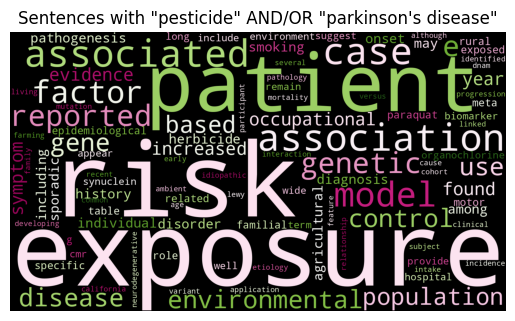

In [58]:
# Sentences with "pesticides" AND/OR "parkinson's disease"
create_wordcloud(
    word_list(
        diff_with_PD_pest
    ),
    collocations= False
)
plt.title('Sentences with "pesticide" AND/OR "parkinson\'s disease"')
plt.show()

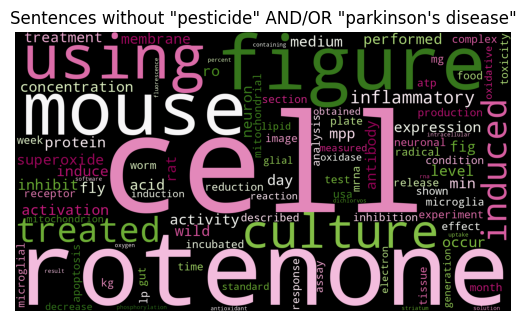

In [59]:
# Sentences without "pesticides", "parkinson's disease"
create_wordcloud(
    word_list(
        diff_without_PD_pest
    ),
    collocations= False
)
plt.title('Sentences without "pesticide" AND/OR "parkinson\'s disease"')
plt.show()

##### "Parkinson's disease"

In [ ]:
# Complete pipeline
filtered_without_PD_pest = filter_word_counts(
    normalize_counts(
        get_word_counts(
            remove_PD_and_pest_from_sentence(
                get_sentences(
                    df["sentence_text"], 
                    ["parkinson's disease"],
                    inverse= True
                ),
                remove_pest= False,
                # remove_word= "parkinson's disease"
            ),
            tokenizer
        ).copy()
    )
)

filtered_with_PD_pest = filter_word_counts(
    normalize_counts(
        get_word_counts(
            remove_PD_and_pest_from_sentence(
                get_sentences(
                    df["sentence_text"], 
                    ["parkinson's disease"]
                ),
                remove_pest= False,
                # remove_word= "parkinson's disease"
            ), 
            tokenizer
        ).copy()
    )
)

# Substract sets
diff_with_PD_pest = subtract_word_counts(filtered_with_PD_pest, filtered_without_PD_pest)
diff_without_PD_pest = subtract_word_counts(filtered_without_PD_pest, filtered_with_PD_pest)

23994 sentences were found without '["parkinson's disease"]'.
total word count: 325430
6490 sentences were found with '["parkinson's disease"]'.
total word count: 98400


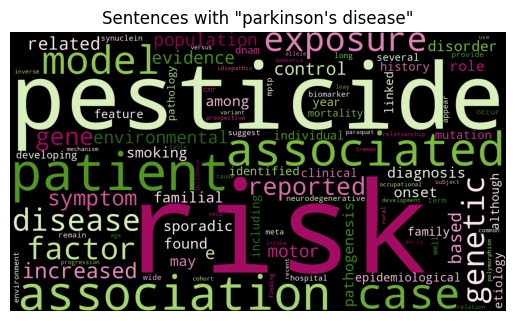

In [51]:
# Sentences with "pesticides" AND/OR "parkinson's disease"
create_wordcloud(
    word_list(
        diff_with_PD_pest
    ),
    collocations= False
)
plt.title('Sentences with "parkinson\'s disease"')
plt.show()

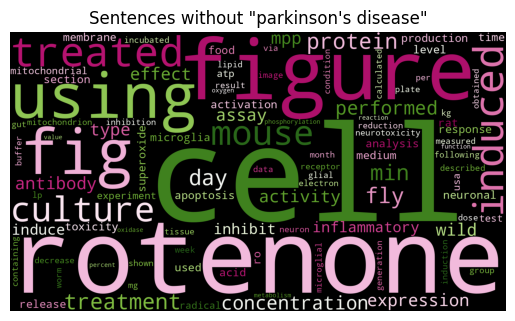

In [47]:
# Sentences without "pesticides", "parkinson's disease"
create_wordcloud(
    word_list(
        diff_without_PD_pest
    ),
    collocations= False
)
plt.title('Sentences without "parkinson\'s disease"')
plt.show()

##### "Pesticides"

In [ ]:
# Complete pipeline
filtered_without_PD_pest = filter_word_counts(
    normalize_counts(
        get_word_counts(
            remove_PD_and_pest_from_sentence(
                get_sentences(
                    df["sentence_text"], 
                    ["pesticide"],
                    inverse= True
                ),
            remove_pest= True,
            ),
            tokenizer
        ).copy()
    )
)

filtered_with_PD_pest = filter_word_counts(
    normalize_counts(
        get_word_counts(
            remove_PD_and_pest_from_sentence(
                get_sentences(
                    df["sentence_text"], 
                    ["pesticide"],
                ),
            remove_pest= True,
            ), 
            tokenizer
        ).copy()
    )
)

# Substract sets
diff_with_PD_pest = subtract_word_counts(filtered_with_PD_pest, filtered_without_PD_pest)
diff_without_PD_pest = subtract_word_counts(filtered_without_PD_pest, filtered_with_PD_pest)

27852 sentences were found without '['pesticide']'.
total word count: 392920
2632 sentences were found with '['pesticide']'.
total word count: 42890


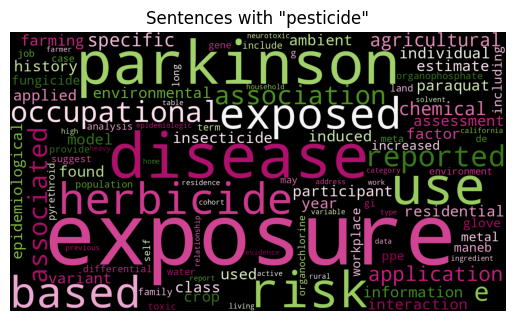

In [53]:
# Sentences with "pesticides" AND/OR "parkinson's disease"
create_wordcloud(
    word_list(
        diff_with_PD_pest
    ),
    collocations= False
)
plt.title('Sentences with "pesticide"')
plt.show()

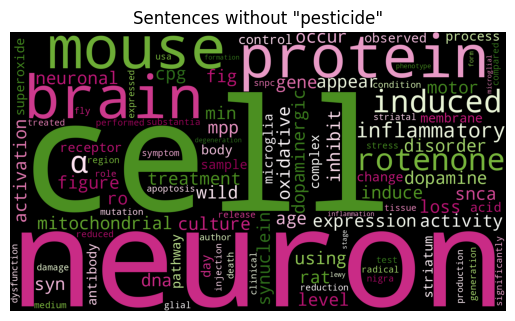

In [54]:
# Sentences without "pesticides", "parkinson's disease"
create_wordcloud(
    word_list(
        diff_without_PD_pest
    ),
    collocations= False
)
plt.title('Sentences without "pesticide"')
plt.show()

### Various other keywords

1370 sentences were found with '['mitochondria']'.


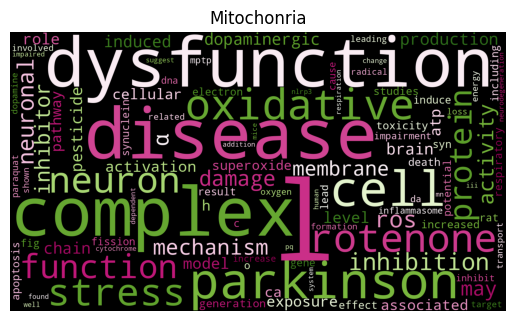

In [55]:
# with Mitochondria
create_wordcloud(
    remove_PD_and_pest_from_sentence(
        get_sentences(
            df["sentence_text"],
            ["mitochondria"]
        ),
    remove_word= "mitochondria",
    remove_PD= False,
    remove_pest= False,
    ),
    collocations= False
)

plt.title("Mitochonria")
plt.show()

In [60]:
# Complete pipeline
filtered_without_PD_pest = filter_word_counts(
    normalize_counts(
        get_word_counts(
            remove_PD_and_pest_from_sentence(
                get_sentences(
                    df["sentence_text"], 
                    ["mitochondria"],
                    inverse= True
                ),
                remove_word= "mitochondria",
            ),
            tokenizer
        ).copy()
    )
)

filtered_with_PD_pest = filter_word_counts(
    normalize_counts(
        get_word_counts(
            remove_PD_and_pest_from_sentence(
                get_sentences(
                    df["sentence_text"], 
                    ["mitochondria"],
                ),
                remove_word= "mitochondria",
            ), 
            tokenizer
        ).copy()
    )
)

# Substract sets
diff_with_PD_pest = subtract_word_counts(filtered_with_PD_pest, filtered_without_PD_pest)
diff_without_PD_pest = subtract_word_counts(filtered_without_PD_pest, filtered_with_PD_pest)

29114 sentences were found without '['mitochondria']'.
total word count: 415821
1370 sentences were found with '['mitochondria']'.
total word count: 21417


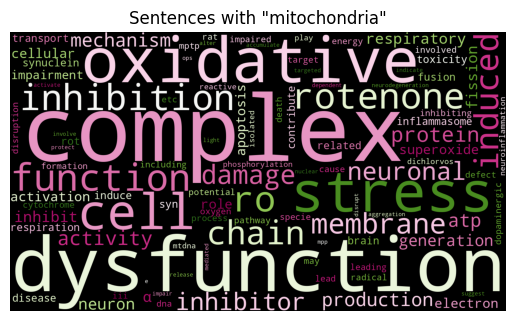

In [61]:
# Sentences with "pesticides" AND/OR "parkinson's disease"
create_wordcloud(
    word_list(
        diff_with_PD_pest
    ),
    collocations= False
)
plt.title('Sentences with "mitochondria"')
plt.show()

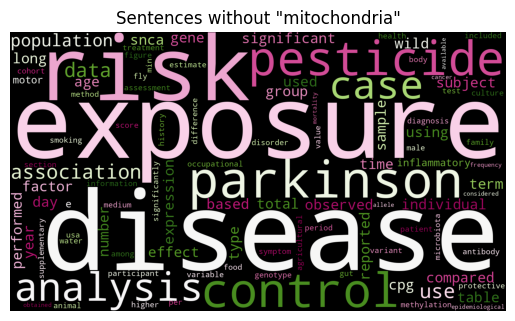

In [62]:
# Sentences without "pesticides", "parkinson's disease"
create_wordcloud(
    word_list(
        diff_without_PD_pest
    ),
    collocations= False
)
plt.title('Sentences without "mitochondria"')
plt.show()

: 

782 sentences were found with '['microglia']'.


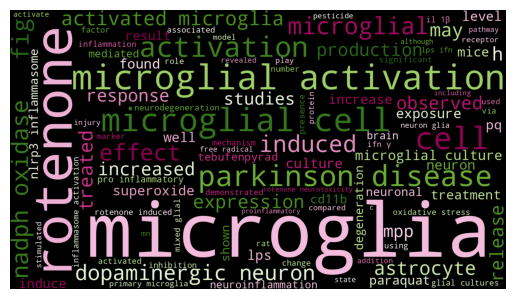

In [123]:
# with Microglia
create_wordcloud(
    get_sentences(
        df["sentence_text"],
        ["microglia"]
    )
)

In [66]:
# Complete pipeline
filtered_without_PD_pest = filter_word_counts(
    normalize_counts(
        get_word_counts(
            remove_PD_and_pest_from_sentence(
                get_sentences(
                    df["sentence_text"], 
                    ["microglia"],
                    inverse= True
                ),
                remove_word= "microglia",
            ),
            tokenizer
        ).copy()
    )
)

filtered_with_PD_pest = filter_word_counts(
    normalize_counts(
        get_word_counts(
            remove_PD_and_pest_from_sentence(
                get_sentences(
                    df["sentence_text"], 
                    ["microglia"],
                ),
                remove_word= "microglia",
            ), 
            tokenizer
        ).copy()
    )
)

# Substract sets
diff_with_PD_pest = subtract_word_counts(filtered_with_PD_pest, filtered_without_PD_pest)
diff_without_PD_pest = subtract_word_counts(filtered_without_PD_pest, filtered_with_PD_pest)

29702 sentences were found without '['microglia']'.
total word count: 426073
782 sentences were found with '['microglia']'.
total word count: 11943


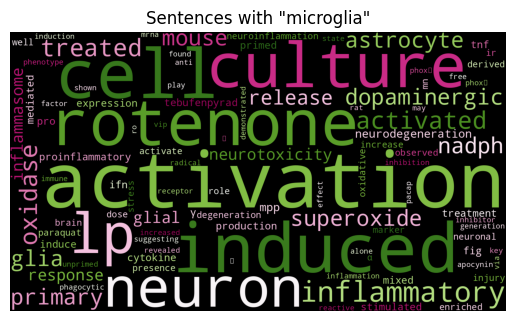

In [67]:
# Sentences with "pesticides" AND/OR "parkinson's disease"
create_wordcloud(
    word_list(
        diff_with_PD_pest
    ),
    collocations= False
)
plt.title('Sentences with "microglia"')
plt.show()

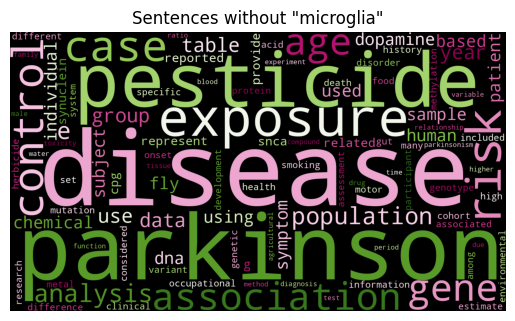

In [68]:
# Sentences without "pesticides", "parkinson's disease"
create_wordcloud(
    word_list(
        diff_without_PD_pest
    ),
    collocations= False
)
plt.title('Sentences without "microglia"')
plt.show()

: 

2193 sentences were found with '['rotenone']'.


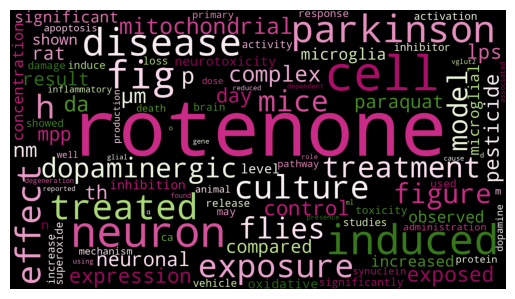

In [136]:
# with Rotenone
create_wordcloud(
    get_sentences(
        df["sentence_text"],
        ["rotenone"]
    ),
    collocations= False
)

889 sentences were found with '['paraquat']'.


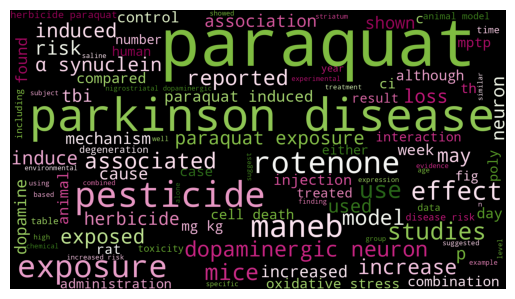

In [131]:
# with Paraquat
create_wordcloud(
    get_sentences(
        df["sentence_text"],
        ["paraquat"]
    )
)

28 sentences were found with '['chlorpyrifos']'.


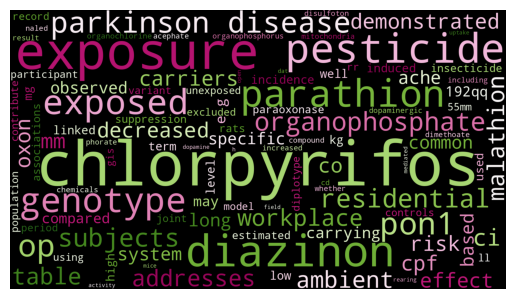

In [132]:
# with Chlorpyrifos
create_wordcloud(
    get_sentences(
        df["sentence_text"],
        ["chlorpyrifos"]
    )
)

In [133]:
# with Acetamiprid
create_wordcloud(
    get_sentences(
        df["sentence_text"],
        ["acetamiprid"]
    )
)

0 sentences were found with '['acetamiprid']'.


ValueError: We need at least 1 word to plot a word cloud, got 0.

In [134]:
# with Pendimethalin
create_wordcloud(
    get_sentences(
        df["sentence_text"],
        ["pendimethalin"]
    )
)

0 sentences were found with '['pendimethalin']'.


ValueError: We need at least 1 word to plot a word cloud, got 0.

## Number of words per sentence

In order to choose the right model for determining sentence similarity, it is helpful to know general properties (e.g. number of words per sentence). Some transformers can only handle a limited amount of words per sentence.

"A common value for BERT-based models are 512 tokens, which corresponds to about 300-400 words (for English)." https://www.sbert.net/examples/sentence_transformer/applications/computing-embeddings/README.html#input-sequence-length 

In [ ]:
# Load model of choice
model_st = SentenceTransformer('NeuML/pubmedbert-base-embeddings')

# Max number of tokens per sentence.
# Longer texts will be truncated to the first model.max_seq_length tokens
# https://www.sbert.net/examples/sentence_transformer/applications/computing-embeddings/README.html#input-sequence-length 
model_st.max_seq_length

: 

The maximum number of words per sentence for our chosen model ('NeuML/pubmedbert-base-embeddings') corresponds to about 300-400 words (for English).

#### Check word count distribution of sentences in our corpus:

Let's find out about our number of words per sentence.

In [ ]:
# Create wordcount series
s_word_count = df['sentence_text'].str.split(' ').map(len)

: 

In [ ]:
# https://matplotlib.org/stable/gallery/text_labels_and_annotations/placing_text_boxes.html
# Plot histogram
s_word_count.plot.hist(bins= 50)

# Get described information
describe_info = df_describe_not_norm(s_word_count).T
textstr = "\n".join([
    f"Count: {describe_info["count"][0]:.0f}",
    f"Median: {describe_info["median"][0]:.0f}",
    f"Minimum: {describe_info["min"][0]:.0f}",
    f"Maximum: {describe_info["max"][0]:.0f}",
    f"Range: {describe_info["range"][0]:.0f}",
])
props = dict(boxstyle='round', 
             facecolor='white', 
             alpha=0.5)
plt.text(
    # 0.05, 
    200,
    6000, 
    # "test", 
    textstr,
    bbox = props, 
    verticalalignment='top'
)

plt.title("Words per sentence distribution")
plt.xlabel("Number of words")
plt.show()

: 

In [ ]:
df_describe_not_norm(s_word_count).T#["count"][0]

: 

It appears somewhat normal distributed with a heavy tail to the right.

Of the 30484 sentences, an median sentence contains 23 words, where the longest sentence is 262 words long.

To use 'Sentence-BERT' for spaCy the sentences need to be shorter than 128.

In [ ]:
# Sentences that are longer than 128 words.
print(f"There are {s_word_count[s_word_count >128].shape[0]} sentences longer than 128.")

: 

##### Long sentences

I'm wondering what these long sentences are.

In [ ]:
# Get index of long sentences
i_long_sentences = s_word_count[s_word_count >128].index

: 

In [ ]:
df.loc[i_long_sentences]

: 

The long sentences appear in different sections throughout a paper.

##### Short sentences

In [ ]:
# Get index of short sentences
i_short_sentences = s_word_count.sort_values()[:50].index

df.loc[i_short_sentences]

: 

The shortest sentences exhibit some noise, which may originate from the PDF-to-XML parsing process or from the regular expression-based sentence extraction method. 

## Number of sentences per paper

Just out of curiosity I looked how many sentences an average paper has.

Number of sentences per paper (see column `sentence_text`):

In [ ]:
# Number of headers, paragraphs, and sentences per paper.
df.groupby('paper_id')[['head_id', 'paragraph_id', 'sentence_text']].nunique()

: 

#### Number of sentences per paper globally described

In [ ]:
s_sent_count = df.groupby('paper_id')[['head_id', 'paragraph_id', 'sentence_text']].nunique()['sentence_text']

: 

In [ ]:
df.groupby('paper_id')[['sentence_text']].nunique().plot.hist(bins= 25)

# Get described information
describe_info = df_describe_not_norm(s_sent_count).T
textstr = "\n".join([
    f"Count: {describe_info["count"][0]:.0f}",
    f"Median: {describe_info["median"][0]:.0f}",
    f"Minimum: {describe_info["min"][0]:.0f}",
    f"Maximum: {describe_info["max"][0]:.0f}",
    f"Range: {describe_info["range"][0]:.0f}",
])
props = dict(boxstyle='round', 
             facecolor='white', 
             alpha=0.5)
plt.text(
    800,
    35,
    textstr,
    bbox = props, 
    verticalalignment='top'
)

plt.title("Sentences per paper distribution")
plt.legend('', frameon=False)
plt.xlabel('Number of sentences')
plt.show()

: 

In [ ]:
df_describe_not_norm(df.groupby('paper_id')[['sentence_text']].nunique()['sentence_text']).T

: 

Of the 152 papers, an median sentence contain 182 sentences, where the longest paper (PMID 21626386) is 1127 sentences long.

In [ ]:
df.groupby('paper_name')[['sentence_text']].nunique().sort_values(by= 'sentence_text', ascending=False)

: 

The 1127 sentences in PMID 21626386 appears not to be a parsing error, for the paper contains 207 pages.

The shortest paper is full of PDF-to-XML parsing errors. This likely due to it being written in French.

In [ ]:
df[df['paper_name'] == 34792911]

: 

The other papers are likely to miss sections that were not pick-up by GROBID.

PMID 28704346 for example misses the abstract and introduction section, though it exists in the PDF.

In [ ]:
df[df['paper_name'] == 28704346]#["sentence_text"].values

: 